# Классификация эмоций: Нейтральная vs Ненейтральная

Сравниваем три подхода на объединённом датасете **RAVDESS + CREMA-D**:
1. **DistilHuBERT → Linear Classifier** — обучение с предобученным аудио-энкодером
2. **Log-Mel Spectrogram → CNN** — 2D-свёрточная сеть на спектрограммах
3. **MFCC → SVM** — классический ML-подход

Метрики сравнения:
- **Качество** — Accuracy, F1 (macro), Precision, Recall
- **Скорость** — время инференса на одном файле (end-to-end)
- **Размер модели** — объём классификатора и всего пайплайна

In [147]:
import os, io, pickle, random, time, gc

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import lightning as L

from transformers import AutoModel, Wav2Vec2FeatureExtractor, set_seed

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

import warnings
warnings.filterwarnings("ignore")


In [148]:
SEED = 42


def seed_everything(seed: int) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        if torch.backends.mps.is_available():
            torch.mps.manual_seed(seed)
    except AttributeError:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    set_seed(seed)


seed_everything(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"Random seed: {SEED}")

results = {}

Device: mps
Random seed: 42


In [149]:
def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2


def sklearn_size_mb(model):
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return buf.tell() / 1024 ** 2

## Загрузка данных RAVDESS + CREMA-D

In [150]:
RAVDESS_PATH = "../datasets/ravdess/"
SAMPLE_RATE_RAVDESS = 48000

file_paths, labels, speakers, sources = [], [], [], []

# ── RAVDESS ──
# Формат: 03-01-{emotion}-01-01-01-{actor}.wav  (emotion ≤ 2 - neutral)
audio_base = os.path.join(RAVDESS_PATH, "Audio_Speech_Actors_01-24")
for actor_dir in sorted(os.listdir(audio_base)):
    if not actor_dir.startswith("Actor_"):
        continue
    for f in sorted(os.listdir(os.path.join(audio_base, actor_dir))):
        if not f.endswith(".wav"):
            continue
        fp = os.path.join(audio_base, actor_dir, f)
        emotion = int(os.path.basename(f).split('-')[2])
        file_paths.append(fp)
        # 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
        labels.append(0 if emotion <= 2 else 1)
        speakers.append(f"rav_{actor_dir.split('_')[1]}")
        sources.append("RAVDESS")

n_rav = len(file_paths)
print("RAVDESS: ", n_rav)

RAVDESS:  1440


In [151]:
CREMA_PATH = "../datasets/crema-d/"
SAMPLE_RATE_CREMAD = 16000
SR = SAMPLE_RATE_CREMAD # will be used as default

# ── CREMA-D ──
# Формат: {actorID}_{sentence}_{EMO}_{intensity}.wav  (NEU - neutral)
for f in sorted(os.listdir(CREMA_PATH)):
    if not f.endswith(".wav"):
        continue
    fp = os.path.join(CREMA_PATH, f)
    parts = f.replace(".wav", "").split("_")
    file_paths.append(fp)
    labels.append(0 if parts[2] == "NEU" else 1)
    speakers.append(f"crm_{parts[0]}")
    sources.append("CREMA-D")

n_crm = len(file_paths) - n_rav

labels = np.array(labels)
speakers = np.array(speakers)
sources = np.array(sources)

print("CREMA-D: ", n_crm)

CREMA-D:  7442


In [152]:
# Speaker-independent split: по 20 % спикеров из каждого датасета - test
test_speakers = set()
for ds in ["RAVDESS", "CREMA-D"]:
    ds_spk = sorted(set(speakers[sources == ds]))
    n_test = max(1, len(ds_spk) // 5)
    test_speakers.update(ds_spk[-n_test:])

train_idx = [i for i, s in enumerate(speakers) if s not in test_speakers]
test_idx  = [i for i, s in enumerate(speakers) if s in test_speakers]

train_files = [file_paths[i] for i in train_idx]
test_files  = [file_paths[i] for i in test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"RAVDESS: {n_rav} файлов | CREMA-D: {n_crm} файлов | Всего: {len(file_paths)}")
print(f"Neutral: {(labels==0).sum()} | Emotional: {(labels==1).sum()}")
print(f"\nSpeaker-independent split (20 % спикеров из каждого датасета):")
print(f"  Train: {len(train_files)} файлов ({len(set(speakers[train_idx]))} спикеров)")
print(f"  Test:  {len(test_files)} файлов ({len(test_speakers)} спикеров)")
print(f"  Train balance — neutral: {(y_train==0).sum()}, emotional: {(y_train==1).sum()}")
print(f"  Test  balance — neutral: {(y_test==0).sum()}, emotional: {(y_test==1).sum()}")

RAVDESS: 1440 файлов | CREMA-D: 7442 файлов | Всего: 8882
Neutral: 1375 | Emotional: 7507

Speaker-independent split (20 % спикеров из каждого датасета):
  Train: 7167 файлов (93 спикеров)
  Test:  1715 файлов (22 спикеров)
  Train balance — neutral: 1112, emotional: 6055
  Test  balance — neutral: 263, emotional: 1452


In [153]:
def load_audio(path):
    y, sr = librosa.load(path, sr=None)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    return y

train_files_loaded = [load_audio(f) for f in train_files]
test_files_loaded = [load_audio(f) for f in test_files]


## Подход 1: audio → DistilHuBERT → Linear Classifier

In [154]:
HUBERT_NAME = "ntu-spml/distilhubert"
hub_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
hub_model = AutoModel.from_pretrained(HUBERT_NAME).to(device).eval()

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

In [155]:
hub_dim = hub_model.config.hidden_size
hub_params = sum(p.numel() for p in hub_model.parameters())
print(f"DistilHuBERT: hidden_size={hub_dim}, params={hub_params:,}")


def hubert_embed(index, train=True):
    file = train_files_loaded[index] if train else test_files_loaded[index]
    inp = hub_extractor(file, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        h = hub_model(**inp).last_hidden_state  # (1, T, hidden_size)
    if train:
        return h.mean(dim=1).squeeze(0).cpu().numpy()  # (hidden_size,)
    return h.mean(dim=1)

print("Извлечение DistilHuBERT-эмбеддингов...")
start_time = time.time()
X_hub_train = np.array([hubert_embed(index) for index in tqdm(range(len(train_files)))])
extract_time = time.time() - start_time

DistilHuBERT: hidden_size=768, params=23,491,968
Извлечение DistilHuBERT-эмбеддингов...


100%|██████████| 7167/7167 [01:56<00:00, 61.62it/s]


In [156]:
X_hub_test  = [hubert_embed(index, train=False) for index in tqdm(range(len(test_files)))]
print(f"Train: {X_hub_train.shape}, Test: {len(X_hub_test)}")

100%|██████████| 1715/1715 [00:27<00:00, 61.83it/s]

Train: (7167, 768), Test: 1715


In [157]:
class LinearClassifier(nn.Module):
    def __init__(self, d, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(d, n_classes)

    def forward(self, x):
        return self.fc(x)


class LinearModule(L.LightningModule):
    def __init__(self, d, X_train, y_train, X_test, y_test, epochs):
        super().__init__()
        self.model = LinearClassifier(d)
        self._xt = torch.tensor(X_train, dtype=torch.float32)
        self._y = y_train
        self._X_test = X_test
        self._y_test = y_test
        self._epochs = epochs
        self._last_loss = None

    def training_step(self, batch, _):
        xb, yb = batch
        self._last_loss = F.cross_entropy(self.model(xb), yb)
        return self._last_loss

    def on_train_epoch_end(self):
        ep = self.current_epoch
        if (ep + 1) % 10 != 0:
            return
        with torch.no_grad():
            train_acc = (
                self.model(self._xt.to(self.device)).argmax(1).cpu().numpy() == self._y
            ).mean()
            preds = [self.model(x.to(self.device)).argmax(1).item() for x in self._X_test]
        test_acc = accuracy_score(self._y_test, preds)
        test_f1 = f1_score(self._y_test, preds, average="macro")
        loss_val = self._last_loss.item() if self._last_loss is not None else float("nan")
        print(f"Epoch {ep+1}/{self._epochs} | Loss {loss_val:.4f} | Train Acc {train_acc:.4f}")
        print(f"Test Acc {test_acc:.4f}, F1 {test_f1:.4f}")

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=1e-3, weight_decay=1e-4)


EPOCHS = 200
ds1 = TensorDataset(
    torch.tensor(X_hub_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader1 = DataLoader(
    ds1,
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

module_1 = LinearModule(hub_dim, X_hub_train, y_train, X_hub_test, y_test, EPOCHS)
trainer_1 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    enable_progress_bar=False,
    logger=False,
    enable_checkpointing=False,
)
t0 = time.time()
trainer_1.fit(module_1, loader1)
train_time_1 = time.time() - t0

model_1 = module_1.model.to(device)

# End-to-end инференс
model_1.eval()
t0 = time.time()
preds_1 = []
for test_index in tqdm(range(len(test_files))):
    y_audio = test_files_loaded[test_index]
    inp = hub_extractor(y_audio, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = hub_model(**inp).last_hidden_state.mean(dim=1)
        preds_1.append(model_1(emb).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_files)
preds_1 = np.array(preds_1)

hub_pipeline_mb = pytorch_size_mb(hub_model) + pytorch_size_mb(model_1)
cls_1_mb = pytorch_size_mb(model_1)

hub_model.cpu()
model_1.cpu()
del hub_model, hub_extractor
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

results['DistilHuBERT_Linear'] = {
    "Модель": "DistilHuBERT + Linear",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": extract_time + train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": hub_pipeline_mb,
}
print(f"\nDistilHuBERT + Linear - Acc={results['DistilHuBERT_Linear']['Accuracy']:.4f} "
      f"F1={results['DistilHuBERT_Linear']['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={hub_pipeline_mb:.1f} MB")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LinearClassifier │  1.5 K │ train │     0 │
└───┴───────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 10/200 | Loss 0.3020 | Train Acc 0.9117
Test Acc 0.8356, F1 0.7526
Epoch 20/200 | Loss 0.1378 | Train Acc 0.9209
Test Acc 0.8624, F1 0.7781
Epoch 30/200 | Loss 0.1481 | Train Acc 0.9259
Test Acc 0.8746, F1 0.7947
Epoch 40/200 | Loss 0.0343 | Train Acc 0.9283
Test Acc 0.8828, F1 0.8048
Epoch 50/200 | Loss 0.1054 | Train Acc 0.9339
Test Acc 0.8776, F1 0.8016
Epoch 60/200 | Loss 0.1751 | Train Acc 0.9287
Test Acc 0.8956, F1 0.8160
Epoch 70/200 | Loss 0.2307 | Train Acc 0.9364
Test Acc 0.8822, F1 0.8065
Epoch 80/200 | Loss 0.1048 | Train Acc 0.9400
Test Acc 0.8834, F1 0.8119
Epoch 90/200 | Loss 0.0733 | Train Acc 0.9297
Test Acc 0.9061, F1 0.8270
Epoch 100/200 | Loss 0.1015 | Train Acc 0.9413
Test Acc 0.8863, F1 0.8129
Epoch 110/200 | Loss 0.1287 | Train Acc 0.9413
Test Acc 0.8910, F1 0.8166
Epoch 120/200 | Loss 0.1339 | Train Acc 0.9429
Test Acc 0.8939, F1 0.8226
Epoch 130/200 | Loss 0.1541 | Train Acc 0.9404
Test Acc 0.8752, F1 0.8059
Epoch 140/200 | Loss 0.0637 | Train Acc 0.9410


`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200 | Loss 0.0487 | Train Acc 0.9438
Test Acc 0.9038, F1 0.8327


100%|██████████| 1715/1715 [00:26<00:00, 64.48it/s]



DistilHuBERT + Linear - Acc=0.9038 F1=0.8327 Inf=15.5 мс/файл  Pipeline=89.6 MB


## Подход 2: audio → Log-Mel Spectrogram → CNN

In [158]:
N_MELS, MAX_LEN, HOP = 64, 128, 512


def extract_log_mel(index, train=True):
    y = train_files_loaded[index] if train else test_files_loaded[index]
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    return lm  # (N_MELS, MAX_LEN)


print("Извлечение log-mel спектрограмм...")
extract_start = time.time()
X_mel_train = np.array([extract_log_mel(index) for index in tqdm(range(len(train_files)))])
extract_time = time.time() - extract_start
X_mel_test  = np.array([extract_log_mel(index, train=False) for index in tqdm(range(len(test_files)))])

mel_mean, mel_std = X_mel_train.mean(), X_mel_train.std()
X_mel_train = (X_mel_train - mel_mean) / (mel_std + 1e-8)
X_mel_test  = (X_mel_test  - mel_mean) / (mel_std + 1e-8)
print(f"Train: {X_mel_train.shape}, Test: {X_mel_test.shape}")

Извлечение log-mel спектрограмм...


100%|██████████| 1715/1715 [00:02<00:00, 675.68it/s]


Train: (7167, 64, 128), Test: (1715, 64, 128)


In [159]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class MelModule(L.LightningModule):
    def __init__(self, model, class_weights, X_train, y_train, X_test, y_test, epochs):
        super().__init__()
        self.model = model
        self.register_buffer("w", class_weights)
        self._xt = torch.tensor(X_train[:, None], dtype=torch.float32)
        self._y = y_train
        self._xt_test = torch.tensor(X_test[:, None], dtype=torch.float32)
        self._y_test = y_test
        self._epochs = epochs
        self._last_loss = None

    def training_step(self, batch, _):
        xb, yb = batch
        self._last_loss = F.cross_entropy(self.model(xb), yb, weight=self.w)
        return self._last_loss

    def on_train_epoch_end(self):
        ep = self.current_epoch
        if (ep + 1) % 10 != 0:
            return
        self.model.eval()
        with torch.no_grad():
            train_preds = self.model(self._xt.to(self.device)).argmax(1).cpu().numpy()
            acc = (train_preds == self._y).mean()
            test_preds = self.model(self._xt_test.to(self.device)).argmax(1).cpu().numpy()
            test_acc = accuracy_score(self._y_test, test_preds)
            test_f1 = f1_score(self._y_test, test_preds, average="macro")
        self.model.train()
        loss_val = self._last_loss.item() if self._last_loss is not None else float("nan")
        lr = self.trainer.optimizers[0].param_groups[0]["lr"]
        print(
            f"Epoch {ep+1}/{self._epochs} | LR {lr:.2e} | Loss {loss_val:.4f} | Train Acc {acc:.4f} | "
            f"Test Acc {test_acc:.4f}, F1 {test_f1:.4f}"
        )

    def configure_optimizers(self):
        opt = optim.Adam(self.model.parameters(), lr=2e-5, weight_decay=2e-6)
        sched = optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=self._epochs, eta_min=1e-7
        )
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "interval": "epoch"},
        }

In [160]:
n_neutral_train = (y_train == 0).sum()
n_emotional_train = (y_train == 1).sum()
n_total_train = len(y_train)
class_weights = torch.tensor(
    [n_total_train / (2 * n_neutral_train), n_total_train / (2 * n_emotional_train)],
    dtype=torch.float32,
)
print(f"Class weights — Neutral: {class_weights[0]:.3f}, Emotional: {class_weights[1]:.3f}")

ds2 = TensorDataset(
    torch.tensor(X_mel_train[:, None], dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader2 = DataLoader(
    ds2,
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED + 1),
)

model_2 = MelCNN(N_MELS, MAX_LEN).to(device)
print(f"CNN params: {sum(p.numel() for p in model_2.parameters()):,}")

EPOCHS = 60
module_2 = MelModule(model_2, class_weights, X_mel_train, y_train, X_mel_test, y_test, EPOCHS)
trainer_2 = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    enable_progress_bar=False,
    logger=False,
    enable_checkpointing=False,
)
t0 = time.time()
trainer_2.fit(module_2, loader2)
train_time_2 = time.time() - t0

model_2 = module_2.model.to(device)

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for index in tqdm(range(len(test_files))):
    y_audio = test_files_loaded[index]
    mel = librosa.feature.melspectrogram(y=y_audio, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    xt = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_2.append(model_2(xt).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_files)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
model_2.cpu()
if torch.backends.mps.is_available():
    gc.collect()
    torch.mps.empty_cache()
gc.collect()

results['Log-Mel_CNN'] = {
    "Модель": "Log-Mel + CNN",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": extract_time + train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": cls_2_mb,
}
print(f"\nLog-Mel + CNN → Acc={results['Log-Mel_CNN']['Accuracy']:.4f} "
      f"F1={results['Log-Mel_CNN']['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Size={cls_2_mb:.2f} MB")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Class weights — Neutral: 3.223, Emotional: 0.592
CNN params: 548,002


┏━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MelCNN │  548 K │ train │     0 │
└───┴───────┴────────┴────────┴───────┴───────┘

Trainable params: 548 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 548 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 10/60 | LR 1.87e-05 | Loss 0.4672 | Train Acc 0.7649 | Test Acc 0.7388, F1 0.6561
Epoch 20/60 | LR 1.50e-05 | Loss 0.3730 | Train Acc 0.8640 | Test Acc 0.7918, F1 0.6878
Epoch 30/60 | LR 1.01e-05 | Loss 0.3306 | Train Acc 0.9132 | Test Acc 0.8175, F1 0.7107
Epoch 40/60 | LR 5.08e-06 | Loss 0.4338 | Train Acc 0.9240 | Test Acc 0.8222, F1 0.7129
Epoch 50/60 | LR 1.43e-06 | Loss 0.1773 | Train Acc 0.9252 | Test Acc 0.8169, F1 0.7081


`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 60/60 | LR 1.00e-07 | Loss 0.0866 | Train Acc 0.9305 | Test Acc 0.8227, F1 0.7128


100%|██████████| 1715/1715 [00:06<00:00, 267.02it/s]



Log-Mel + CNN → Acc=0.8227 F1=0.7128 Inf=3.7 мс/файл  Size=2.09 MB


## Подход 3: audio → MFCC → SVM

In [161]:
N_MFCC = 40


def extract_mfcc_stats(path, train=True):
    """MFCC + delta + delta2, агрегированные по времени (mean, std)."""
    y = train_files_loaded[index] if train else test_files_loaded[index]
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([
        mfcc.mean(1), mfcc.std(1),
        d1.mean(1),   d1.std(1),
        d2.mean(1),   d2.std(1),
    ])  # (N_MFCC * 6,) = (240,)


print("Извлечение MFCC-признаков...")
extract_start = time.time()
X_mfcc_train = np.array([extract_mfcc_stats(f) for f in tqdm(train_files)])
extract_time = time.time() - extract_start
X_mfcc_test  = np.array([extract_mfcc_stats(f, train=False) for f in tqdm(test_files)])

scaler = StandardScaler()
X_mfcc_train_s = scaler.fit_transform(X_mfcc_train)
X_mfcc_test_s  = scaler.transform(X_mfcc_test)
print(f"Feature dim: {X_mfcc_train_s.shape[1]}")

t0 = time.time()
model_3 = SVC(kernel="rbf", C=10, gamma="scale", random_state=SEED)
model_3.fit(X_mfcc_train_s, y_train)
train_time_3 = time.time() - t0
print(f"SVM обучен за {train_time_3:.1f} сек | "
      f"Train Acc: {model_3.score(X_mfcc_train_s, y_train):.4f}")

# End-to-end инференс
t0 = time.time()
preds_3 = []
for f in test_files:
    feat = extract_mfcc_stats(f)
    preds_3.append(model_3.predict(scaler.transform(feat.reshape(1, -1)))[0])
inf_time_3 = (time.time() - t0) / len(test_files)
preds_3 = np.array(preds_3)

svm_mb = sklearn_size_mb(model_3)
scaler_mb = sklearn_size_mb(scaler)

results['MFCC_SVM'] = {
    "Модель": "MFCC + SVM",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": extract_time + train_time_3,
    "Классификатор (MB)": svm_mb,
    "Пайплайн (MB)": svm_mb + scaler_mb,
}
print(f"\nMFCC + SVM → Acc={results['MFCC_SVM']['Accuracy']:.4f} "
      f"F1={results['MFCC_SVM']['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Size={svm_mb:.2f} MB")

Извлечение MFCC-признаков...


100%|██████████| 1715/1715 [00:03<00:00, 446.11it/s]


Feature dim: 240
SVM обучен за 1.0 сек | Train Acc: 0.8448

MFCC + SVM → Acc=0.8466 F1=0.4585 Inf=3.1 мс/файл  Size=4.12 MB


## Сохранение весов

In [162]:
import os, json, pickle

CKPT_DIR = os.path.join("..", "trained_models", "audio_neutral")
os.makedirs(CKPT_DIR, exist_ok=True)


def _save_state_dict(name, module):
    path = os.path.join(CKPT_DIR, f"{name}.pt")
    torch.save(module.state_dict(), path)
    print(f"Saved {path}")


def _save_sklearn(name, obj):
    path = os.path.join(CKPT_DIR, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved {path}")


_save_state_dict("linear_classifier", model_1)
_save_state_dict("mel_cnn", model_2)
_save_sklearn("svm", model_3)
_save_sklearn("svm_scaler", scaler)

with open(os.path.join(CKPT_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(
        {
            "SR": int(SR),
            "N_MELS": int(N_MELS),
            "MAX_LEN": int(MAX_LEN),
            "HOP": int(HOP),
            "N_MFCC": int(N_MFCC),
            "mel_mean": float(mel_mean),
            "mel_std": float(mel_std),
            "hub_dim": int(hub_dim),
        },
        f,
        indent=2,
    )
print(f"meta.json → {os.path.join(CKPT_DIR, 'meta.json')}")
print(f"Готово: {os.path.abspath(CKPT_DIR)}")

Saved ../trained_models/audio_neutral/linear_classifier.pt
Saved ../trained_models/audio_neutral/mel_cnn.pt
Saved ../trained_models/audio_neutral/svm.pkl
Saved ../trained_models/audio_neutral/svm_scaler.pkl
meta.json → ../trained_models/audio_neutral/meta.json
Готово: /Users/kaparya/Desktop/Diploma/trained_models/audio_neutral


## Сводная таблица и визуализация

In [163]:
results_df = [value for _, value in results.items()]
df = pd.DataFrame(results_df)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(
    index=False,
    formatters={k: v.format for k, v in fmt.items()},
))

for name, preds in [
    ("DistilHuBERT + Linear", preds_1),
    ("Log-Mel + CNN", preds_2),
    ("MFCC + SVM", preds_3),
]:
    print(f"\n{'=' * 55}")
    print(f"{name}")
    print(classification_report(y_test, preds, target_names=["Neutral", "Emotional"]))

               Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
DistilHuBERT + Linear   0.9038     0.8327    0.8063 0.8700               15.5          224.4              0.006         89.62
        Log-Mel + CNN   0.8227     0.7128    0.6906 0.7583                3.7          133.8              2.091          2.09
           MFCC + SVM   0.8466     0.4585    0.4233 0.5000                3.1           20.7              4.116          4.12

DistilHuBERT + Linear
              precision    recall  f1-score   support

     Neutral       0.65      0.82      0.72       263
   Emotional       0.97      0.92      0.94      1452

    accuracy                           0.90      1715
   macro avg       0.81      0.87      0.83      1715
weighted avg       0.92      0.90      0.91      1715


Log-Mel + CNN
              precision    recall  f1-score   support

     Neutral       0.45      0.67      0.54       263
   Emotional       0.9

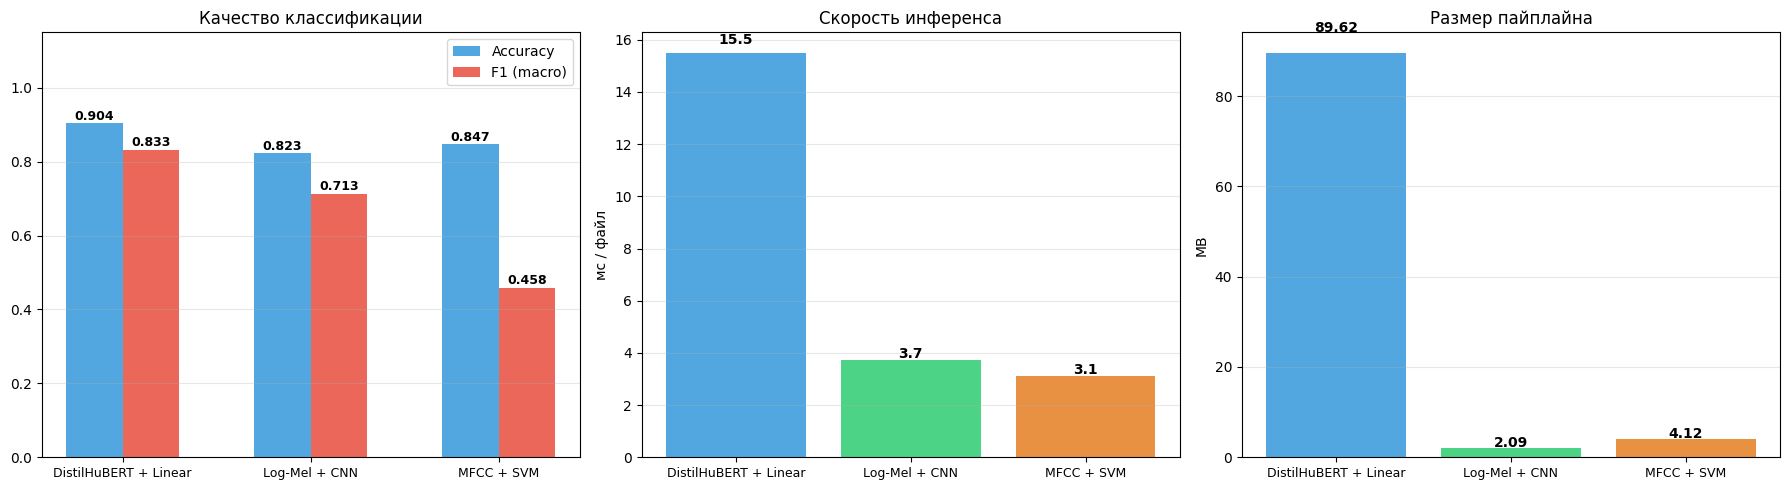

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = df["Модель"].tolist()
x = np.arange(len(models))
colors = ["#3498db", "#2ecc71", "#e67e22"]

# ── Качество ──
w = 0.3
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_title("Качество классификации")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(
        b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
        f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold",
    )

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
        f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold",
    )

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
        f"{b.get_height():.2f}", ha="center", fontsize=10, fontweight="bold",
    )

plt.tight_layout()
plt.show()